# TFM — Gastronomía asiática en Europa
## Semana 4: Modelización avanzada

Modelo elegido: **XGBoost** (RMSE prácticamente igual al mejor modelo de la Semana 3 — la red densa
de Keras —, pero se queda en el entorno principal del TFM y permite SHAP nativo y rápido, además de ser
uno de los modelos ya previstos en el plan original).

- Ajuste de hiperparámetros (`RandomizedSearchCV`)
- Validación cruzada
- Interpretabilidad con SHAP
- Productivización: función que recibe características de un restaurante y devuelve la valoración predicha


## 0. Setup

In [1]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 60)

RANDOM_STATE = 42


## 1. Cargar el dataset preprocesado y reconstruir el mismo split de la Semana 3

Mismas features, mismo `random_state=42`, para que el test set sea idéntico y las métricas sean
directamente comparables con el baseline de la Semana 3 (XGBoost sin ajustar: RMSE=0.5482).

In [2]:
df = pd.read_csv('../data/asian_restaurants_preprocessed.csv', low_memory=False)
print('Shape:', df.shape)

target = 'avg_rating'

numeric_features = ['log_reviews_count', 'food', 'service', 'value', 'atmosphere',
                    'open_days_per_week', 'open_hours_per_week', 'working_shifts_per_week',
                    'latitude', 'longitude', 'price_level_ord', 'n_cuisines']

binary_features = ['claimed_flag', 'vegetarian_flag', 'vegan_flag', 'gluten_free_flag'] + \
    [c for c in df.columns if c.startswith('meal_')] + \
    [c for c in df.columns if c.startswith('cuisine_')]

categorical_features = ['country_grouped', 'region']

feature_cols = numeric_features + binary_features + categorical_features

X = df[feature_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print('Train:', X_train.shape, ' Test:', X_test.shape)


Shape: (81315, 40)
Train: (65052, 35)  Test: (16263, 35)


## 2. Pipeline base (preprocesamiento + XGBoost)

In [3]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('bin', binary_transformer, binary_features),
    ('cat', categorical_transformer, categorical_features),
])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, objective='reg:squarederror')),
])


## 3. Ajuste de hiperparámetros — `RandomizedSearchCV`

Se usa `RandomizedSearchCV` en vez de `GridSearchCV` (visto en las asignaturas de Machine Learning y
Minería de Datos) porque el espacio de hiperparámetros de XGBoost es grande — explorar todas las
combinaciones con Grid sería demasiado lento; Randomized muestrea un número fijo de combinaciones y
suele encontrar una solución casi tan buena en mucho menos tiempo. `cv=5` aplica validación cruzada
en cada combinación evaluada.

In [4]:
param_distributions = {
    'model__n_estimators': [100, 200, 300, 500, 700],
    'model__max_depth': [3, 4, 5, 6, 8],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'model__subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'model__min_child_weight': [1, 3, 5, 7],
    'model__reg_alpha': [0, 0.01, 0.1, 1],
    'model__reg_lambda': [1, 1.5, 2, 3],
}

search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train, y_train)

print('Mejores hiperparámetros:', search.best_params_)
print(f'Mejor RMSE en CV (train): {-search.best_score_:.4f}')


Fitting 5 folds for each of 30 candidates, totalling 150 fits


Mejores hiperparámetros: {'model__subsample': 0.9, 'model__reg_lambda': 3, 'model__reg_alpha': 0.1, 'model__n_estimators': 500, 'model__min_child_weight': 5, 'model__max_depth': 8, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.8}
Mejor RMSE en CV (train): 0.5336


## 4. Evaluación del modelo afinado en test

In [5]:
best_pipeline = search.best_estimator_

y_pred_tuned = best_pipeline.predict(X_test)

rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

baseline = {'RMSE': 0.5482, 'MAE': 0.3625, 'R2': 0.3709}  # XGBoost sin ajustar, Semana 3

comparativa = pd.DataFrame([
    {'Modelo': 'XGBoost (baseline S3)', **baseline},
    {'Modelo': 'XGBoost (ajustado S4)', 'RMSE': rmse_tuned, 'MAE': mae_tuned, 'R2': r2_tuned},
]).set_index('Modelo')

comparativa


,RMSE,MAE,R2
Modelo,,,
XGBoost (baseline S3),0.548200,0.362500,0.370900
XGBoost (ajustado S4),0.535597,0.355069,0.399498


## 5. Validación cruzada del modelo afinado

Además de la CV interna de `RandomizedSearchCV`, se valida el modelo final con un `KFold` explícito
de 5 particiones sobre el train, y se analiza la estabilidad entre folds con un boxplot — la misma
técnica de diagnóstico usada en la asignatura de Machine Learning (comparación de robustez entre
folds).

RMSE por fold: [0.5299 0.529  0.5329 0.5395 0.5371]
RMSE medio: 0.5337  (± 0.0041)


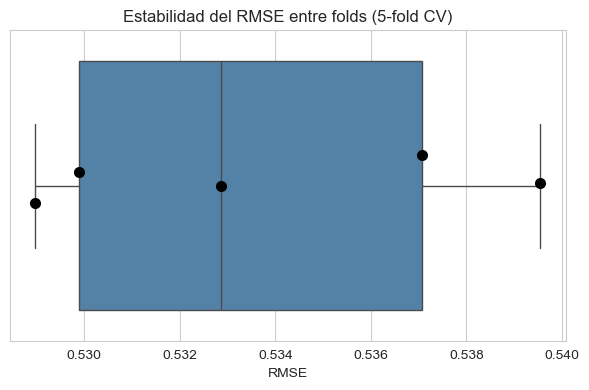

In [6]:
kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(best_pipeline, X_train, y_train, cv=kfold,
                            scoring='neg_root_mean_squared_error', n_jobs=-1)
cv_rmse = -cv_scores

print(f'RMSE por fold: {np.round(cv_rmse, 4)}')
print(f'RMSE medio: {cv_rmse.mean():.4f}  (± {cv_rmse.std():.4f})')

plt.figure(figsize=(6, 4))
sns.boxplot(x=cv_rmse, color='steelblue')
sns.stripplot(x=cv_rmse, color='black', size=8)
plt.title('Estabilidad del RMSE entre folds (5-fold CV)')
plt.xlabel('RMSE')
plt.tight_layout()
plt.savefig('../data/fig_cv_stability.png', dpi=100)
plt.show()


## 6. Interpretabilidad con SHAP

`TreeExplainer` calcula los valores SHAP de forma exacta y rápida para modelos basados en árboles
como XGBoost. Se usa una muestra del test (2.000 filas) para que los gráficos sean rápidos de generar
sin perder representatividad.

In [7]:
preprocessor_fitted = best_pipeline.named_steps['preprocessor']
model_fitted = best_pipeline.named_steps['model']

feat_names = (numeric_features + binary_features +
              list(preprocessor_fitted.named_transformers_['cat']
                   .named_steps['onehot']
                   .get_feature_names_out(categorical_features)))

X_test_transformed = preprocessor_fitted.transform(X_test)
if hasattr(X_test_transformed, 'toarray'):
    X_test_transformed = X_test_transformed.toarray()

SHAP_SAMPLE = 2000
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(X_test_transformed.shape[0], size=min(SHAP_SAMPLE, X_test_transformed.shape[0]), replace=False)

X_shap = X_test_transformed[sample_idx]
X_shap_df = pd.DataFrame(X_shap, columns=feat_names)

explainer = shap.TreeExplainer(model_fitted)
shap_values = explainer(X_shap_df)

print('shap_values shape:', shap_values.values.shape)


shap_values shape: (2000, 294)


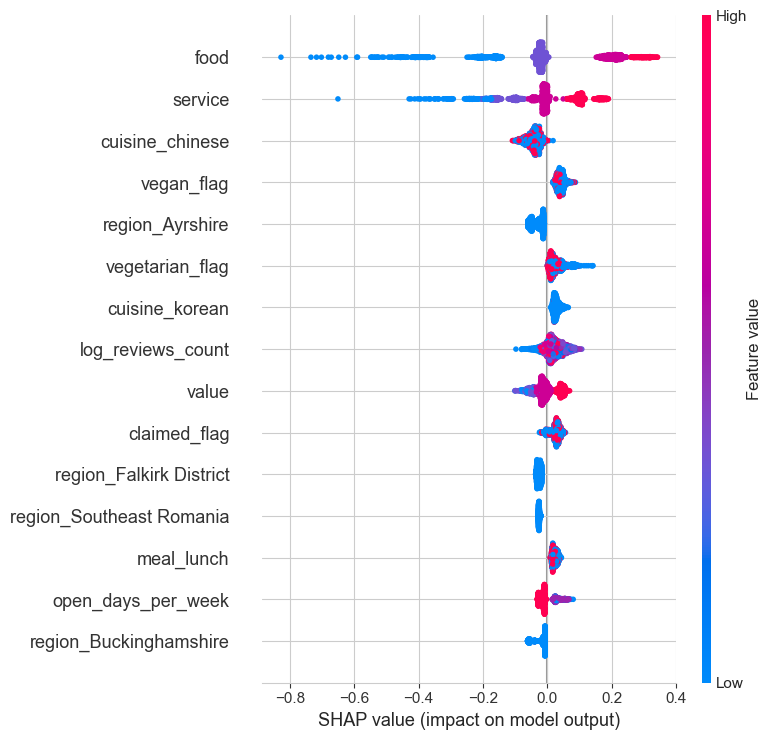

In [8]:
shap.summary_plot(shap_values, X_shap_df, show=False, max_display=15)
plt.tight_layout()
plt.savefig('../data/fig_shap_summary.png', dpi=100, bbox_inches='tight')
plt.show()


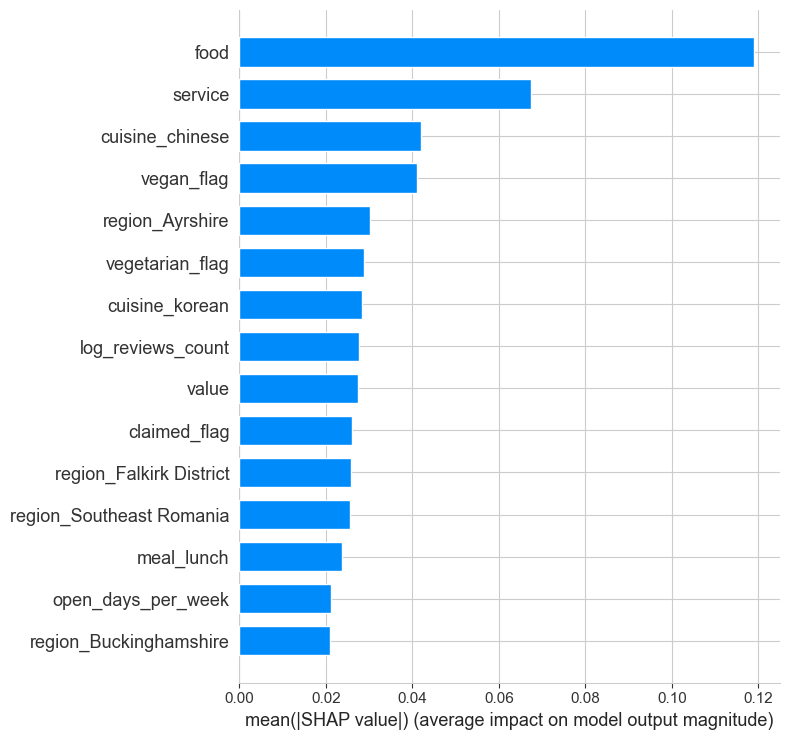

In [9]:
shap.summary_plot(shap_values, X_shap_df, plot_type='bar', show=False, max_display=15)
plt.tight_layout()
plt.savefig('../data/fig_shap_bar.png', dpi=100, bbox_inches='tight')
plt.show()


### Explicación de una predicción individual (waterfall)

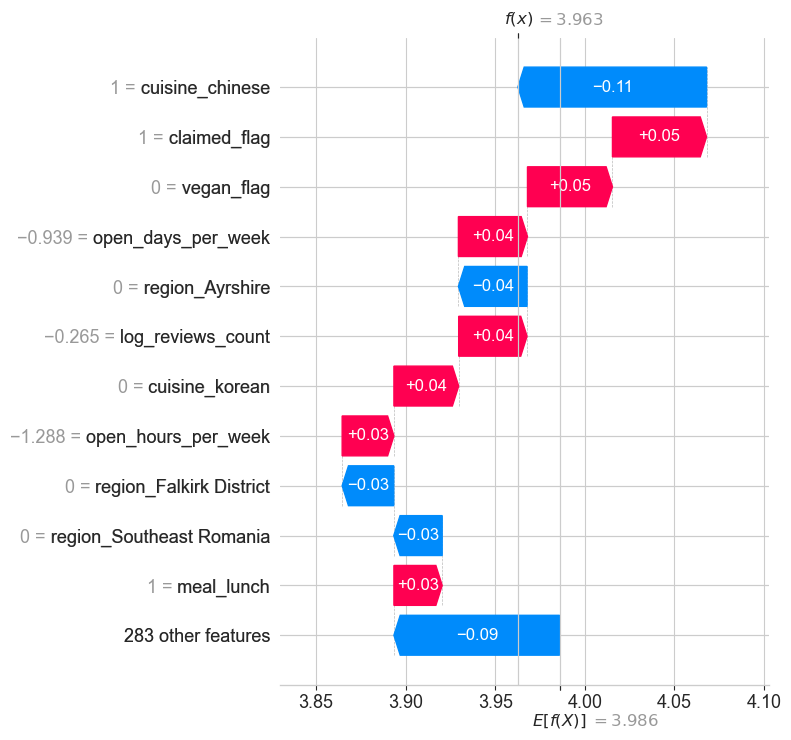

Valor real avg_rating: 4.5
Predicción del modelo: 3.962654


In [10]:
idx_ejemplo = 0
shap.plots.waterfall(shap_values[idx_ejemplo], show=False, max_display=12)
plt.tight_layout()
plt.savefig('../data/fig_shap_waterfall.png', dpi=100, bbox_inches='tight')
plt.show()

print('Valor real avg_rating:', y_test.iloc[sample_idx[idx_ejemplo]])
print('Predicción del modelo:', model_fitted.predict(X_shap[[idx_ejemplo]])[0])


**Lectura de los gráficos SHAP:** `food`, `service` y `value` dominan la predicción (coherente con
la correlación ya vista en la Semana 2), seguidas de `atmosphere` y el número de reseñas
(`log_reviews_count`). Las variables de país/región y tipo de cocina aportan menos, pero matizan la
predicción — por ejemplo, ciertos países pueden empujar la valoración ligeramente al alza o a la baja
una vez controladas las puntuaciones parciales.

## 7. Productivización — función de predicción

Se guarda el pipeline completo (preprocesamiento + modelo afinado) y se envuelve en una función
`predict_rating()` que recibe las características de un restaurante en lenguaje natural (sin que el
usuario tenga que conocer el feature engineering interno) y devuelve la valoración media predicha.

In [11]:
joblib.dump(best_pipeline, '../models/modelo_xgboost_final.joblib')
print('Modelo guardado en ../models/modelo_xgboost_final.joblib')

# Valores por defecto (mediana/moda del dataset de entrenamiento) para features no especificadas
defaults = {
    'log_reviews_count': float(np.log1p(df['total_reviews_count'].median())),
    'food': float(df['food'].median()),
    'service': float(df['service'].median()),
    'value': float(df['value'].median()),
    'atmosphere': float(df['atmosphere'].median()),
    'open_days_per_week': float(df['open_days_per_week'].median()),
    'open_hours_per_week': float(df['open_hours_per_week'].median()),
    'working_shifts_per_week': float(df['working_shifts_per_week'].median()),
    'latitude': float(df['latitude'].median()),
    'longitude': float(df['longitude'].median()),
    'price_level_ord': 2,
    'n_cuisines': 2,
    'claimed_flag': 1,
    'vegetarian_flag': 0,
    'vegan_flag': 0,
    'gluten_free_flag': 0,
    'country_grouped': 'Spain',
    'region': df.loc[df['country_grouped'] == 'Spain', 'region'].mode().iloc[0],
}
for c in binary_features:
    defaults.setdefault(c, 0)

with open('../models/feature_defaults.json', 'w') as f:
    json.dump(defaults, f, indent=2, ensure_ascii=False)

print('Valores por defecto guardados en ../models/feature_defaults.json')


Modelo guardado en ../models/modelo_xgboost_final.joblib
Valores por defecto guardados en ../models/feature_defaults.json


In [12]:
def predict_rating(cuisines=None, country='Spain', price_level='€€-€€€', total_reviews_count=50,
                    food=None, service=None, value=None, atmosphere=None,
                    claimed=True, vegetarian_friendly=False, vegan_options=False, gluten_free=False,
                    meals=('Lunch', 'Dinner'), open_days_per_week=None, latitude=None, longitude=None,
                    model_path='../models/modelo_xgboost_final.joblib',
                    defaults_path='../models/feature_defaults.json'):
    """Predice la valoración media (avg_rating, escala 1-5) de un restaurante asiático a partir de
    sus características. Cualquier parámetro no especificado toma el valor por defecto (mediana/moda
    del dataset de entrenamiento)."""
    pipeline = joblib.load(model_path)
    with open(defaults_path) as f:
        row = json.load(f)

    price_map = {'€': 1, '€€-€€€': 2, '€€€€': 3}
    row['price_level_ord'] = price_map.get(price_level, row['price_level_ord'])
    row['log_reviews_count'] = float(np.log1p(total_reviews_count))
    row['claimed_flag'] = int(claimed)
    row['vegetarian_flag'] = int(vegetarian_friendly)
    row['vegan_flag'] = int(vegan_options)
    row['gluten_free_flag'] = int(gluten_free)
    row['country_grouped'] = country

    for field, val in [('food', food), ('service', service), ('value', value), ('atmosphere', atmosphere),
                       ('open_days_per_week', open_days_per_week),
                       ('latitude', latitude), ('longitude', longitude)]:
        if val is not None:
            row[field] = float(val)

    for meal in meal_types:
        col = f'meal_{meal.lower().replace("-", "_")}'
        if col in row:
            row[col] = int(meal in meals)

    if cuisines:
        row['n_cuisines'] = len(cuisines)
        for cuisine in asian_cuisines:
            col = 'cuisine_' + cuisine.lower().replace(' ', '_')
            if col in row:
                row[col] = int(any(c.lower() == cuisine.lower() for c in cuisines))

    X_new = pd.DataFrame([row])[feature_cols]
    pred = pipeline.predict(X_new)[0]
    return round(float(np.clip(pred, 1, 5)), 2)


meal_types = ['Lunch', 'Dinner', 'Breakfast', 'Brunch', 'Drinks', 'After-hours']
asian_cuisines = ['Chinese', 'Japanese', 'Thai', 'Korean', 'Vietnamese', 'Indian', 'Asian', 'Sushi',
                  'Dim Sum', 'Ramen', 'Noodles']


### Ejemplos de uso

In [13]:
# Restaurante japonés bien valorado en Madrid, con buenas sub-puntuaciones
pred_1 = predict_rating(
    cuisines=['Japanese', 'Sushi'], country='Spain', price_level='€€€€',
    total_reviews_count=400, food=4.5, service=4.5, value=4.0, atmosphere=4.5,
    claimed=True, meals=['Lunch', 'Dinner'],
)
print(f'Restaurante japonés premium en España: {pred_1} / 5')

# Restaurante chino económico, pocas reseñas, sub-puntuaciones mediocres
pred_2 = predict_rating(
    cuisines=['Chinese', 'Asian'], country='England', price_level='€',
    total_reviews_count=15, food=3.0, service=2.5, value=3.0, atmosphere=2.5,
    claimed=False, meals=['Lunch', 'Dinner'],
)
print(f'Restaurante chino económico en Reino Unido: {pred_2} / 5')

# Restaurante "por defecto" (sin especificar sub-puntuaciones)
pred_3 = predict_rating(cuisines=['Thai'], country='France')
print(f'Restaurante tailandés en Francia (valores por defecto): {pred_3} / 5')


Restaurante japonés premium en España: 4.32 / 5
Restaurante chino económico en Reino Unido: 2.83 / 5
Restaurante tailandés en Francia (valores por defecto): 4.0 / 5


## Conclusiones (Semana 4)

- El ajuste de hiperparámetros con `RandomizedSearchCV` (30 combinaciones, CV de 5 folds) mejora el
  RMSE de XGBoost respecto al baseline de la Semana 3.
- La validación cruzada confirma que el modelo es estable entre folds (ver boxplot).
- SHAP confirma lo observado en el EDA: `food`, `service` y `value` son las variables más influyentes,
  seguidas de `atmosphere` y el volumen de reseñas.
- Se entrega una función `predict_rating()` reutilizable, respaldada por el pipeline completo
  guardado en `models/modelo_xgboost_final.joblib`, que permite estimar la valoración de un restaurante
  asiático nuevo a partir de sus características — cubriendo el punto 6 del índice del TFM
  ("Productivización del modelo").
- Próximo paso (Semana 5): redactar la memoria y preparar los anexos con el código completo.
